In [1]:
!pip install gymnasium

Starting training...
Episode: 0/500, Score: 16.0, Epsilon: 1.00
Episode: 50/500, Score: 167.0, Epsilon: 0.01
Episode: 100/500, Score: 443.0, Epsilon: 0.01
Episode: 150/500, Score: 9.0, Epsilon: 0.01
Episode: 200/500, Score: 10.0, Epsilon: 0.01
Episode: 250/500, Score: 500.0, Epsilon: 0.01
Episode: 300/500, Score: 10.0, Epsilon: 0.01
Episode: 350/500, Score: 131.0, Epsilon: 0.01
Episode: 400/500, Score: 9.0, Epsilon: 0.01
Episode: 450/500, Score: 500.0, Epsilon: 0.01


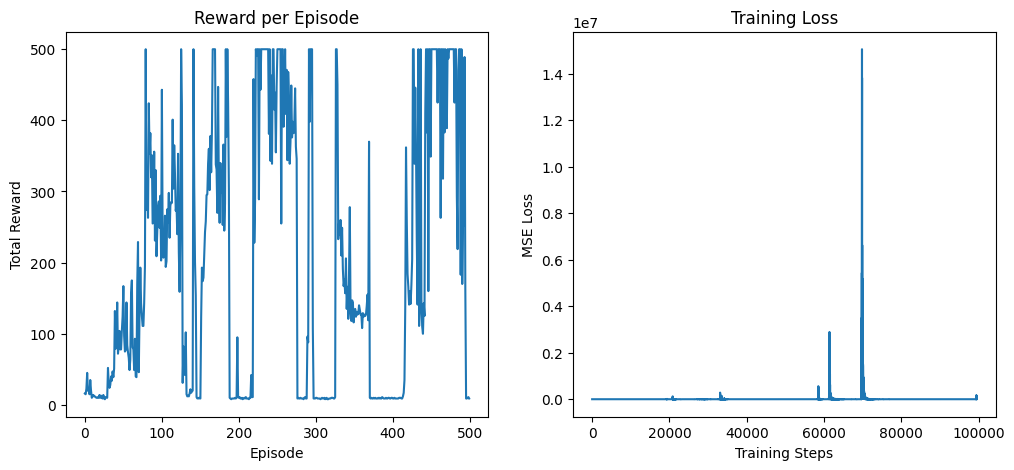

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

# 1. Define the Q-Network
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# 2. Define the Agent with Experience Replay
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=10000)

        # Hyperparameters
        self.gamma = 0.99    # discount rate
        self.epsilon = 1.0   # exploration rate
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.batch_size = 64

        self.model = QNetwork(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.criterion = nn.MSELoss()
        self.loss_history = []

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.model(state_tensor)
        return np.argmax(q_values.numpy())

    def replay(self):
        if len(self.memory) < self.batch_size:
            return

        minibatch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*minibatch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(dones).unsqueeze(1)

        # Current Q values
        curr_q = self.model(states).gather(1, actions)

        # Expected Q values (Target)
        with torch.no_grad():
            next_q = self.model(next_states).max(1)[0].unsqueeze(1)
            target_q = rewards + (self.gamma * next_q * (1 - dones))

        # Optimize the model
        loss = self.criterion(curr_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.loss_history.append(loss.item())

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# 3. Training Loop (Using Modern Gymnasium API)
env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
agent = DQNAgent(state_size, action_size)

episodes = 500
reward_history = []

print("Starting training...")
for e in range(episodes):
    state, info = env.reset() # New API expects two returned values
    total_reward = 0
    done = False

    while not done:
        action = agent.act(state)

        # New API returns 5 values
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.remember(state, action, reward, next_state, done)
        agent.replay()

        state = next_state
        total_reward += reward

    reward_history.append(total_reward)
    if e % 50 == 0:
        print(f"Episode: {e}/{episodes}, Score: {total_reward}, Epsilon: {agent.epsilon:.2f}")

# 4. Plotting Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(reward_history)
plt.title('Reward per Episode')
plt.xlabel('Episode')
plt.ylabel('Total Reward')

plt.subplot(1, 2, 2)
plt.plot(agent.loss_history)
plt.title('Training Loss')
plt.xlabel('Training Steps')
plt.ylabel('MSE Loss')
plt.show()